# BNPL Default Risk Analysis
Predicting customer default risk for Buy Now, Pay Later transactions using synthetic data modeled on real-world BNPL patterns (Tabby/Tamara-style use case).

**Goal:** Build a classification model to predict repayment behavior and segment customers into actionable risk tiers for approval decisions.

## 1. Load and Inspect the Data
Loading the BNPL dataset and checking its structure, column types, and missing values.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/bnpl_dataset_v2.csv')

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (50000, 13)

Column types:
 Transaction_ID           object
Customer_Age              int64
Gender                   object
Annual_Income             int64
Credit_Score              int64
Purchase_Category        object
BNPL_Provider            object
Purchase_Amount           int64
Device_Type              object
Connection_Type          object
Checkout_Time_Seconds     int64
Browser                  object
Repayment_Status         object
dtype: object

Missing values:
 Transaction_ID           0
Customer_Age             0
Gender                   0
Annual_Income            0
Credit_Score             0
Purchase_Category        0
BNPL_Provider            0
Purchase_Amount          0
Device_Type              0
Connection_Type          0
Checkout_Time_Seconds    0
Browser                  0
Repayment_Status         0
dtype: int64


,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Device_Type,Connection_Type,Checkout_Time_Seconds,Browser,Repayment_Status
0,705eef54-52b2-4912-b562-d9f7b4184a6d,56,Male,32293,353,Beauty,Sezzle,249,Tablet,WiFi,82,Firefox,Paid On Time
1,7dbe58a0-0177-4572-8f3a-566d907e9c56,46,Male,72774,354,Groceries,Affirm,188,Mobile,WiFi,60,Firefox,Paid On Time
2,b77e4be3-bf88-4bb0-addb-45d84e6a3f65,32,Male,82207,630,Travel,Sezzle,1610,Desktop,WiFi,86,Chrome,Paid On Time
3,5c3c24a8-675e-46fd-8312-4ac37cbb97c5,60,Male,92498,470,Fashion,Sezzle,120,Mobile,4G/5G,169,Chrome,Paid On Time
4,4bb92076-f15e-4cfc-8aac-58395d69aedc,25,Male,32060,502,Travel,Klarna,1849,Mobile,4G/5G,38,Chrome,Defaulted


## 2. Target Variable Distribution
Examining the split between Paid On Time, Late Payment, and Defaulted customers.

In [4]:
print(df['Repayment_Status'].value_counts())
print("\nPercentage breakdown:")
print(df['Repayment_Status'].value_counts(normalize=True) * 100)

Repayment_Status
Paid On Time    38399
Late Payment     7364
Defaulted        4237
Name: count, dtype: int64

Percentage breakdown:
Repayment_Status
Paid On Time    76.798
Late Payment    14.728
Defaulted        8.474
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis
Visualizing how Credit Score and Annual Income relate to repayment behavior.


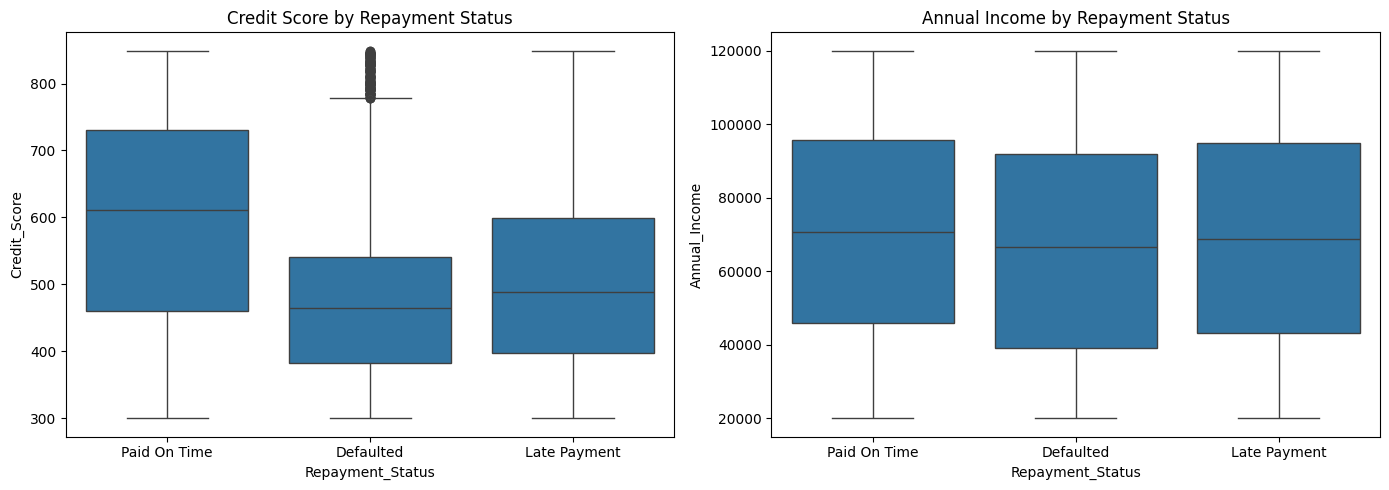

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Repayment_Status', y='Credit_Score', ax=axes[0])
axes[0].set_title('Credit Score by Repayment Status')

sns.boxplot(data=df, x='Repayment_Status', y='Annual_Income', ax=axes[1])
axes[1].set_title('Annual Income by Repayment Status')

plt.tight_layout()
plt.show()

## 4. Encode Categorical Variables
Converting text-based columns into numeric format for machine learning.

In [6]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

categorical_cols = ['Gender', 'Purchase_Category', 'BNPL_Provider',
                     'Device_Type', 'Connection_Type', 'Browser']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

# Encode the target separately so we can map it back later
target_encoder = LabelEncoder()
df_model['Repayment_Status_Encoded'] = target_encoder.fit_transform(df_model['Repayment_Status'])

print("Target classes:", target_encoder.classes_)
df_model.head()

Target classes: ['Defaulted' 'Late Payment' 'Paid On Time']


,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Device_Type,Connection_Type,Checkout_Time_Seconds,Browser,Repayment_Status,Repayment_Status_Encoded
0,705eef54-52b2-4912-b562-d9f7b4184a6d,56,1,32293,353,0,3,249,2,2,82,2,Paid On Time,2
1,7dbe58a0-0177-4572-8f3a-566d907e9c56,46,1,72774,354,3,0,188,1,2,60,2,Paid On Time,2
2,b77e4be3-bf88-4bb0-addb-45d84e6a3f65,32,1,82207,630,5,3,1610,0,2,86,0,Paid On Time,2
3,5c3c24a8-675e-46fd-8312-4ac37cbb97c5,60,1,92498,470,2,3,120,1,0,169,0,Paid On Time,2
4,4bb92076-f15e-4cfc-8aac-58395d69aedc,25,1,32060,502,5,2,1849,1,0,38,0,Defaulted,0


## 5. Feature Selection and Train/Test Split
Preparing input features and splitting data into training and testing sets.

In [7]:
from sklearn.model_selection import train_test_split

feature_cols = ['Customer_Age', 'Gender', 'Annual_Income', 'Credit_Score',
                 'Purchase_Category', 'BNPL_Provider', 'Purchase_Amount',
                 'Device_Type', 'Connection_Type', 'Checkout_Time_Seconds', 'Browser']

X = df_model[feature_cols]
y = df_model['Repayment_Status_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 40000
Testing rows: 10000


## 6. Logistic Regression Model
Training an interpretable baseline model with balanced class weights to handle imbalanced data.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

## 7. Random Forest Model
Training a more powerful ensemble model for improved risk prediction.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

## 8. Model Evaluation
Comparing precision, recall, and F1-score across both models to assess real-world usefulness.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== Logistic Regression Results ===")
print(classification_report(y_test, log_preds, target_names=target_encoder.classes_))

print("\n=== Random Forest Results ===")
print(classification_report(y_test, rf_preds, target_names=target_encoder.classes_))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

   Defaulted       0.15      0.59      0.24       847
Late Payment       0.19      0.17      0.18      1473
Paid On Time       0.87      0.61      0.72      7680

    accuracy                           0.54     10000
   macro avg       0.41      0.46      0.38     10000
weighted avg       0.71      0.54      0.60     10000


=== Random Forest Results ===
              precision    recall  f1-score   support

   Defaulted       0.21      0.50      0.30       847
Late Payment       0.20      0.39      0.26      1473
Paid On Time       0.89      0.58      0.70      7680

    accuracy                           0.55     10000
   macro avg       0.43      0.49      0.42     10000
weighted avg       0.73      0.55      0.60     10000



## 9. Feature Importance
Identifying which factors most influence default risk predictions.

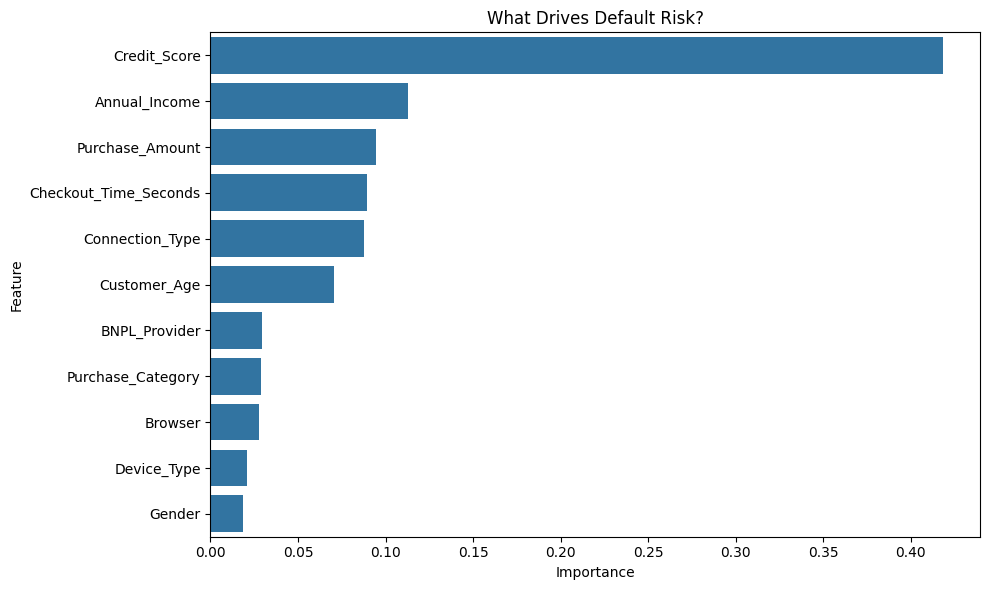

                  Feature  Importance
3            Credit_Score    0.418527
2           Annual_Income    0.112974
6         Purchase_Amount    0.094604
9   Checkout_Time_Seconds    0.089573
8         Connection_Type    0.087487
0            Customer_Age    0.070700
5           BNPL_Provider    0.029731
4       Purchase_Category    0.029015
10                Browser    0.027916
7             Device_Type    0.021144
1                  Gender    0.018329


In [11]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('What Drives Default Risk?')
plt.tight_layout()
plt.show()

print(importance_df)

## 10. Risk Segmentation
Converting model predictions into Low, Medium, and High risk categories for business use.

In [12]:
# Get probability of default for each customer
probs = rf_model.predict_proba(X)
defaulted_class_index = list(target_encoder.classes_).index('Defaulted')
df['Default_Probability'] = probs[:, defaulted_class_index]

def assign_risk(prob):
    if prob < 0.15:
        return 'Low Risk'
    elif prob < 0.35:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['Risk_Segment'] = df['Default_Probability'].apply(assign_risk)

print(df['Risk_Segment'].value_counts())

Risk_Segment
Low Risk       22239
High Risk      14062
Medium Risk    13699
Name: count, dtype: int64


## 11. Export Results for Power BI
Saving the final dataset with predictions and risk segments for dashboard visualization.

In [13]:
df.to_csv('bnpl_results_for_powerbi.csv', index=False)
print("Saved! Download it from the Colab file panel on the left.")

Saved! Download it from the Colab file panel on the left.
